In [16]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

In [17]:
# Load the ECG data from the text file
file_path = r'C:\Users\diyu2\OneDrive - AUT University\AUT YEAR 4\INDUSTRIAL PROJECT (Mechanical)\Reports Part B\testing_ecg.txt'

In [18]:
def load_ecg_data_from_text_file(file_path):
    try:
        # Read the entire file as text
        with open(file_path, 'r') as file:
            lines = file.readlines()

        ecg_data = []
        labels = []  # Adjust this based on how you want to generate labels

        for line in lines:
            # Split the line by whitespace and try to convert to float
            try:
                values = list(map(float, line.split()))
                if len(values) > 0:  # Ensure there's data in the line
                    ecg_data.append(values)  # Store the ECG signal
                    # Placeholder for label assignment logic
                    labels.append(0)  # Update this to assign actual labels as needed
            except ValueError:
                continue  # Skip lines that cannot be converted to float

        return np.array(ecg_data), np.array(labels)
    
    except Exception as e:
        print(f"Error loading text file {file_path}: {e}")
        return None, None

In [19]:
# Convert the list of ECG signals to a NumPy array
data = np.array(data)

In [20]:
# Check the shape of the data
print(f'Data shape: {data.shape}')  # This should now show (number_of_samples, 5000)

Data shape: (12, 5000)


In [21]:
# Assuming each ECG recording is one sample, and the number of time steps is equal to the number of readings per line
X = data.reshape(data.shape[0], data.shape[1], 1)  # Reshape to (samples, time_steps, channels)

# Generate dummy labels for demonstration (binary classification)
num_samples = X.shape[0]
y = np.random.randint(0, 2, num_samples)  # Replace with actual labels

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define model
model = Sequential()

# First convolutional layer
model.add(Conv1D(filters=64, kernel_size=5, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2))

# Second convolutional layer
model.add(Conv1D(filters=128, kernel_size=3, activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2))

# Third convolutional layer
model.add(Conv1D(filters=256, kernel_size=3, activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2))

# Flatten the output
model.add(Flatten())

# Dense layers with regularization
model.add(Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)))
model.add(Dropout(0.5))

# Output layer
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

# Early stopping to prevent overfitting
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)  
    
# Train the model with callbacks
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test),
                    callbacks=[early_stopping])

C:\Users\diyu2\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step - accuracy: 0.5556 - loss: 1.1886 - val_accuracy: 0.6667 - val_loss: 11.1320
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 717ms/step - accuracy: 0.8889 - loss: 0.6655 - val_accuracy: 0.3333 - val_loss: 14.4716
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 720ms/step - accuracy: 1.0000 - loss: 0.5090 - val_accuracy: 0.3333 - val_loss: 16.6087
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 707ms/step - accuracy: 1.0000 - loss: 0.5079 - val_accuracy: 0.3333 - val_loss: 17.7208
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 716ms/step - accuracy: 1.0000 - loss: 0.5067 - val_accuracy: 0.3333 - val_loss: 18.2302
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 709ms/step - accuracy: 1.0000 - loss: 0.5055 - val_accuracy: 0.3333 - val_loss: 18.4297


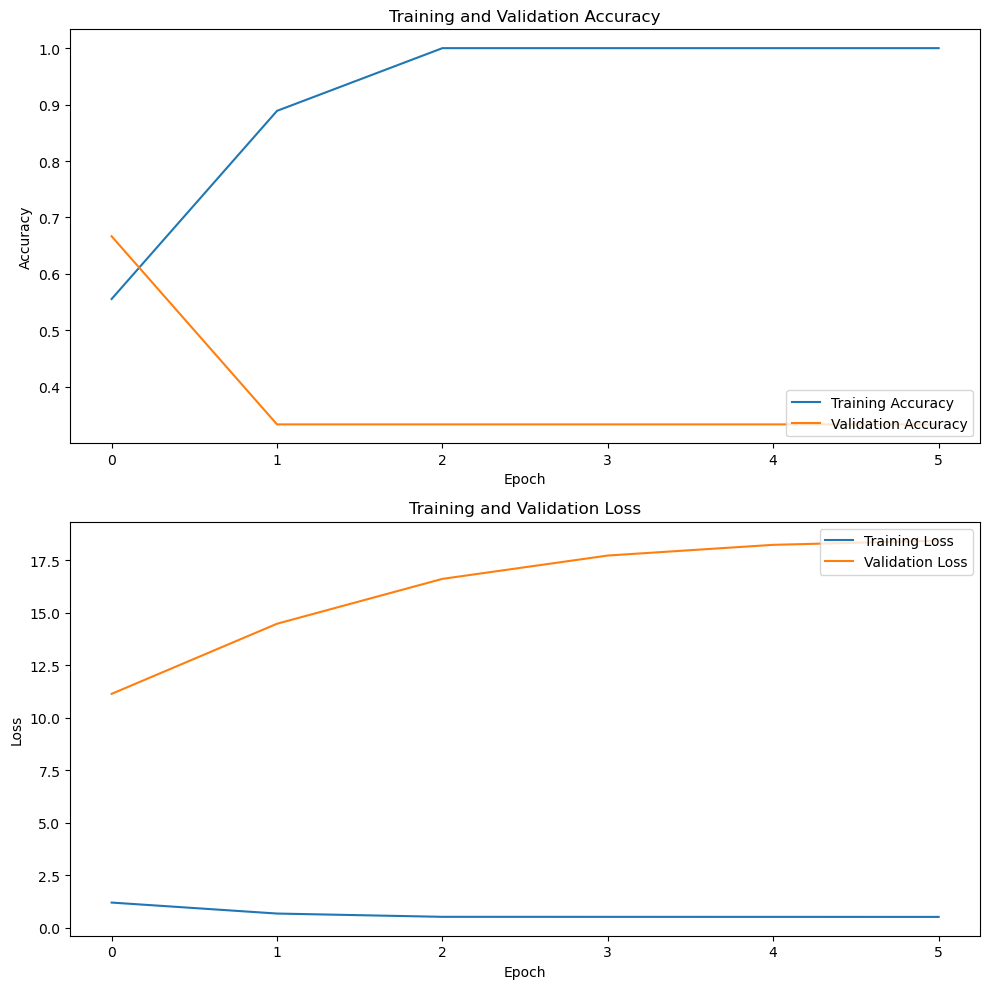


Test Accuracy: 66.67%


In [26]:
# Plotting the training and validation accuracy and loss
fig, axs = plt.subplots(2, 1, figsize=(10, 10))

# Accuracy plot
axs[0].plot(history.history['accuracy'], label='Training Accuracy')
axs[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Accuracy')
axs[0].set_title('Training and Validation Accuracy')
axs[0].legend(loc='lower right')

# Loss plot
axs[1].plot(history.history['loss'], label='Training Loss')
axs[1].plot(history.history['val_loss'], label='Validation Loss')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Loss')
axs[1].set_title('Training and Validation Loss')
axs[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

# Evaluate the model on the test data
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f'\nTest Accuracy: {test_acc * 100:.2f}%')


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 513ms/step


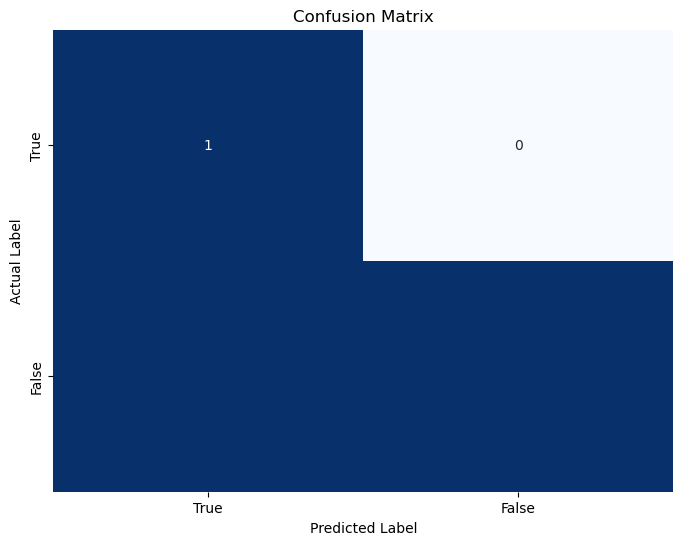

              precision    recall  f1-score   support

           0       0.50      1.00      0.67         1
           1       1.00      0.50      0.67         2

    accuracy                           0.67         3
   macro avg       0.75      0.75      0.67         3
weighted avg       0.83      0.67      0.67         3



In [23]:
# Confusion matrix plotting function
def plot_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
                xticklabels=class_names, yticklabels=class_names)
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.title('Confusion Matrix')
    plt.show()

# Predict on the test set
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)  # Threshold for binary classification

# Define class names based on your dataset
class_names = ['True', 'False']  # Adjust for more classes if necessary

# Plot confusion matrix
plot_confusion_matrix(y_test, y_pred, class_names)

# Classification report for additional metrics
print(classification_report(y_test, y_pred))